In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jrandom
import optax
import matplotlib.pyplot as plt
import diffrax
from tqdm.notebook import tqdm
import random
import numpy as np

['xy_train', 'alpha_train', 'xy_test']
Alpha: -0.8385395699296931


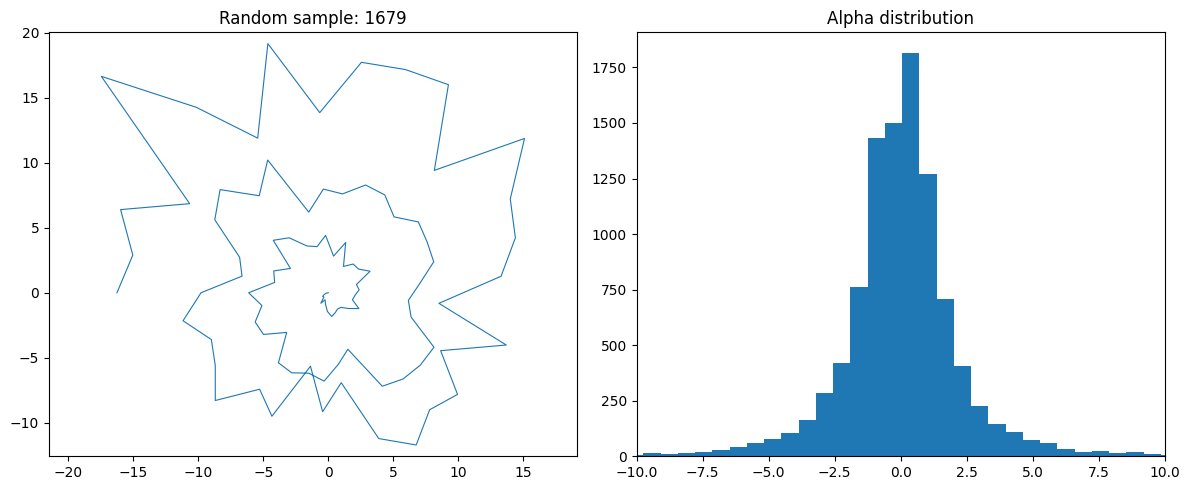

In [21]:
spirals_data = jnp.load("spirals.npz")

print(spirals_data.files)

xy_train = spirals_data["xy_train"]  # (10000, 100, 2)
xy_test = spirals_data["xy_test"]  # (10000, 100, 2)
alpha_train = spirals_data["alpha_train"]  # (10000, 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rand_idx = random.randint(0, xy_train.shape[0] - 1)

print(f"Alpha: {alpha_train[rand_idx, 0]}")

# connect the dots for a random training sample
axes[0].plot(xy_train[rand_idx, :, 0], xy_train[rand_idx, :, 1], linewidth=0.8)
axes[0].set_title(f"Random sample: {rand_idx}")
axes[0].axis("equal")

# alpha distribution
axes[1].hist(alpha_train.flatten(), bins=100)
axes[1].set_xlim(-10, 10)
axes[1].set_title("Alpha distribution")

plt.tight_layout()
plt.show()

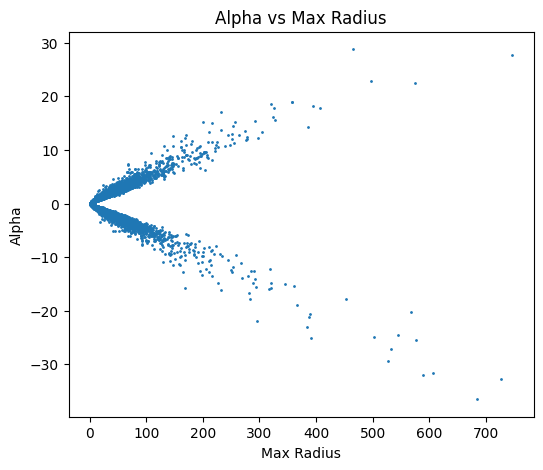

In [ ]:
max_radii = []
for i in range(xy_train.shape[0]):
    radius = (xy_train[i, -1, 0]**2 + xy_train[i, -1, 1]**2) ** 0.5
    max_radii.append(radius)

max_radii = jnp.array(max_radii)

# scatter plot of alpha vs max radius
plt.figure(figsize=(6, 5))
plt.scatter(max_radii.flatten(), alpha_train.flatten(), s=1)
plt.xlabel("Max Radius")
plt.ylabel("Alpha")
plt.title("Alpha vs Max Radius")
plt.show()

Text(0.5, 1.0, 'Alpha vs Last Y')

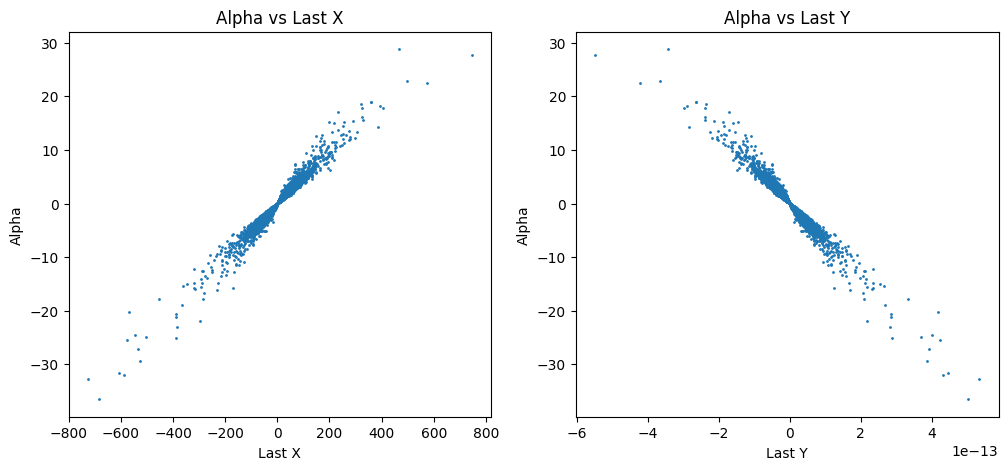

In [26]:
last_x = xy_train[:, -1, 0]
last_y = xy_train[:, -1, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# scatter of last_x vs alpha
axes[0].scatter(last_x.flatten(), alpha_train.flatten(), s=1)
axes[0].set_xlabel("Last X")
axes[0].set_ylabel("Alpha")
axes[0].set_title("Alpha vs Last X")

# scatter of last_y vs alpha
axes[1].scatter(last_y.flatten(), alpha_train.flatten(), s=1)
axes[1].set_xlabel("Last Y")
axes[1].set_ylabel("Alpha")
axes[1].set_title("Alpha vs Last Y")

Text(0.5, 1.0, 'Alpha vs First Y')

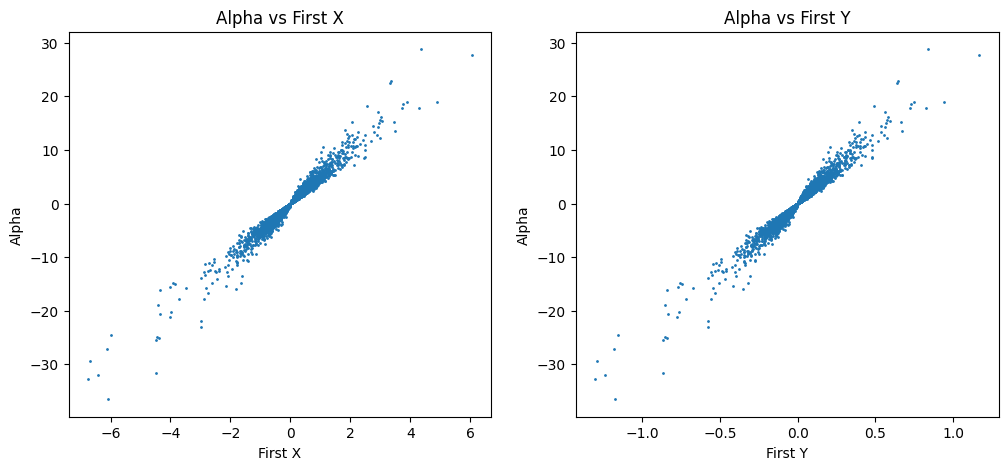

In [28]:
last_x = xy_train[:, 1, 0]
last_y = xy_train[:, 1, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# scatter of last_x vs alpha
axes[0].scatter(last_x.flatten(), alpha_train.flatten(), s=1)
axes[0].set_xlabel("First X")
axes[0].set_ylabel("Alpha")
axes[0].set_title("Alpha vs First X")

# scatter of last_y vs alpha
axes[1].scatter(last_y.flatten(), alpha_train.flatten(), s=1)
axes[1].set_xlabel("First Y")
axes[1].set_ylabel("Alpha")
axes[1].set_title("Alpha vs First Y")